conda create -n wgs_pipeline -y
conda activate wgs_pipeline
 
conda install -c bioconda -c conda-forge -y \
    fastqc multiqc trimmomatic bwa samtools \
    gatk4 snpeff sra-tools snakemake
 
conda install -c conda-forge -y \
    pandas matplotlib seaborn jupyter cyvcf2



#### Make Project Directory

In [ ]:
mkdir -p GenomeQuest-WGS/{data,reference,qc_reports/{pre_trim,post_trim},
    trimmed_reads,alignment,variants,annotation,scripts,notebooks,logs}
cd GenomeQuest-WGS


: 

Total variants called: 31844
PASS variants: 31470
High/Moderate impact: 0
Saved: notebooks/figures/variant_summary.png


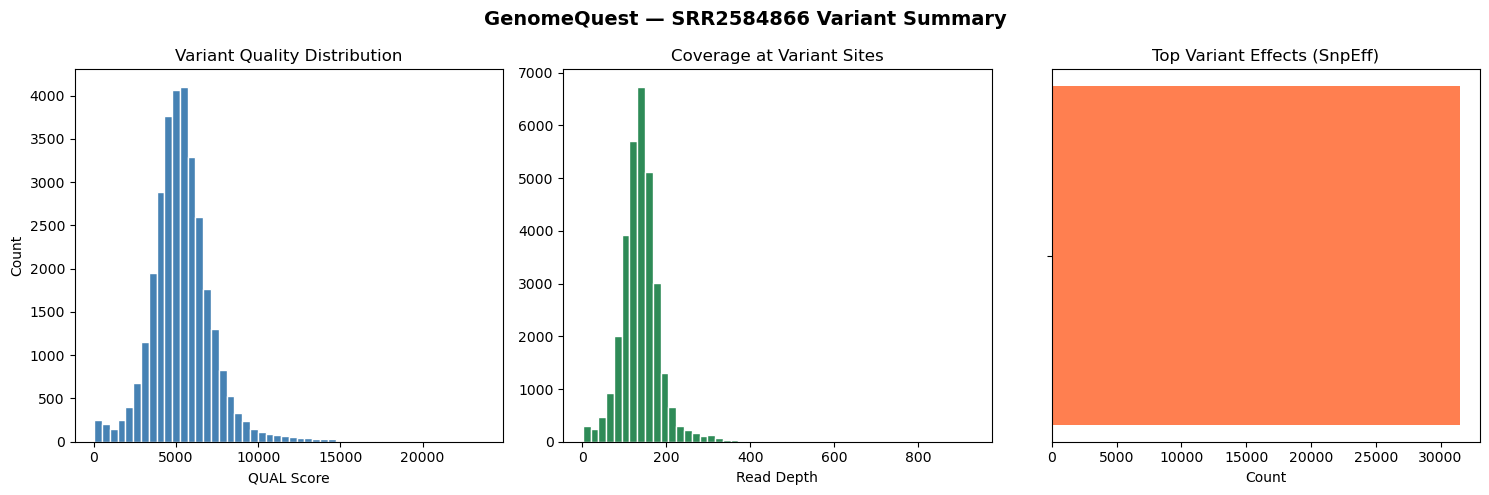

In [1]:
import cyvcf2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
import os
 
os.makedirs('notebooks/figures', exist_ok=True)
 
# ── Parse VCF ──
vcf_path = '/Users/yuks/Desktop/Sequencing-/WGS/annotation/annotated_snps.vcf'
vcf = cyvcf2.VCF(vcf_path)
 
records = []
for variant in vcf:
    info = dict(variant.INFO)
    ann_field = info.get('ANN')

    if ann_field:
        ann = ann_field.split(',')[0].split('|')
    else:
        ann = [''] * 10
    records.append({
        'chrom': variant.CHROM,
        'pos': variant.POS,
        'ref': variant.REF,
        'alt': str(variant.ALT[0]) if variant.ALT else '.',
        'qual': variant.QUAL,
        'depth': variant.INFO.get('DP', 0),
        'filter': variant.FILTER or 'PASS',
        'effect': ann[1] if len(ann) > 1 else 'unknown',
        'impact': ann[2] if len(ann) > 2 else 'unknown',
        'gene': ann[3] if len(ann) > 3 else 'unknown',
    })
 
df = pd.DataFrame(records)
df_pass = df[df['filter'] == 'PASS']
 
print(f'Total variants called: {len(df)}')
print(f'PASS variants: {len(df_pass)}')
print(f'High/Moderate impact: {len(df_pass[df_pass["impact"].isin(["HIGH","MODERATE"])])}')
 
# ── Plot 1: Quality Score Distribution ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('GenomeQuest — SRR2584866 Variant Summary', fontsize=14, fontweight='bold')
 
axes[0].hist(df_pass['qual'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('QUAL Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Variant Quality Distribution')
 
# ── Plot 2: Coverage Depth ──
axes[1].hist(df_pass['depth'], bins=50, color='seagreen', edgecolor='white')
axes[1].set_xlabel('Read Depth')
axes[1].set_title('Coverage at Variant Sites')
 
# ── Plot 3: Effect Type ──
effects = df_pass['effect'].value_counts().head(10)
axes[2].barh(effects.index, effects.values, color='coral')
axes[2].set_xlabel('Count')
axes[2].set_title('Top Variant Effects (SnpEff)')
axes[2].invert_yaxis()
 
plt.tight_layout()
plt.savefig('notebooks/figures/variant_summary.png', dpi=150, bbox_inches='tight')
print('Saved: notebooks/figures/variant_summary.png')
